Anastassiya Ryabkova

#Task 1.1

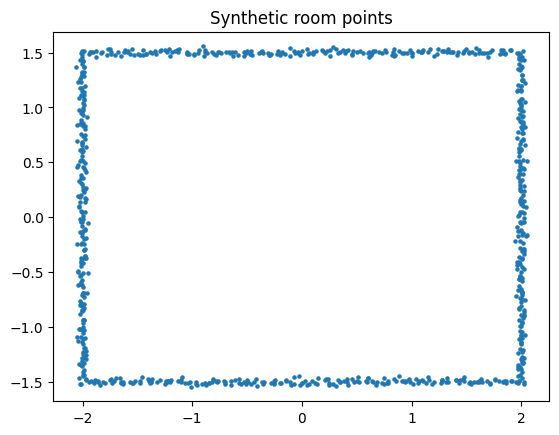

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

def generate_room_points(width=4.0, height=3.0, n_per_wall=200, noise=0.02):
    # Four walls: rectangle centered at (0,0)
    x1 = np.linspace(-width/2, width/2, n_per_wall)
    y1 = -height/2 * np.ones_like(x1)

    x2 = np.linspace(-width/2, width/2, n_per_wall)
    y2 =  height/2 * np.ones_like(x2)

    y3 = np.linspace(-height/2, height/2, n_per_wall)
    x3 = -width/2 * np.ones_like(y3)

    y4 = np.linspace(-height/2, height/2, n_per_wall)
    x4 =  width/2 * np.ones_like(y4)

    x = np.concatenate([x1, x2, x3, x4])
    y = np.concatenate([y1, y2, y3, y4])

    x += np.random.normal(scale=noise, size=x.shape)
    y += np.random.normal(scale=noise, size=y.shape)

    return x, y

x, y = generate_room_points()
plt.figure()
plt.scatter(x, y, s=5)
plt.axis('equal')
plt.title("Synthetic room points")
plt.show()


In [2]:
def cartesian_to_polar(x, y):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)  # radians in [-pi, pi]
    return r, theta

def polar_to_cartesian(r, theta):
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

# Check round-trip
r, th = cartesian_to_polar(x, y)
x_rec, y_rec = polar_to_cartesian(r, th)

print("Max reconstruction error:", np.max(np.abs(x - x_rec)), np.max(np.abs(y - y_rec)))


Max reconstruction error: 6.661338147750939e-16 6.661338147750939e-16


In [3]:
def hough_lines(x, y, num_thetas=180, rho_res=0.01):
    # Parameter ranges
    thetas = np.linspace(-np.pi/2, np.pi/2, num_thetas)
    max_rho = np.hypot(x.max(), y.max())
    min_rho = -max_rho
    rhos = np.arange(min_rho, max_rho + rho_res, rho_res)

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    for xi, yi in zip(x, y):
        for t_idx, theta in enumerate(thetas):
            rho = xi * np.cos(theta) + yi * np.sin(theta)
            r_idx = int(np.round((rho - min_rho) / rho_res))
            if 0 <= r_idx < len(rhos):
                accumulator[r_idx, t_idx] += 1

    return accumulator, rhos, thetas

acc, rhos, thetas = hough_lines(x, y)
print("Accumulator shape:", acc.shape)


Accumulator shape: (517, 180)


In [4]:
def find_hough_peaks(accumulator, num_peaks=4, threshold_ratio=0.5, nhood_size=10):
    acc = accumulator.copy()
    peaks = []
    max_val = acc.max()
    threshold = threshold_ratio * max_val

    for _ in range(num_peaks):
        idx = np.unravel_index(np.argmax(acc), acc.shape)
        if acc[idx] < threshold:
            break
        peaks.append(idx)

        # Suppress neighborhood
        r_idx, t_idx = idx
        r_start = max(r_idx - nhood_size//2, 0)
        r_end   = min(r_idx + nhood_size//2 + 1, acc.shape[0])
        t_start = max(t_idx - nhood_size//2, 0)
        t_end   = min(t_idx + nhood_size//2 + 1, acc.shape[1])
        acc[r_start:r_end, t_start:t_end] = 0

    return peaks

peaks = find_hough_peaks(acc, num_peaks=4)
print("Peaks:", peaks)


Peaks: [(np.int64(408), np.int64(179)), (np.int64(108), np.int64(179)), (np.int64(108), np.int64(0)), (np.int64(408), np.int64(0))]


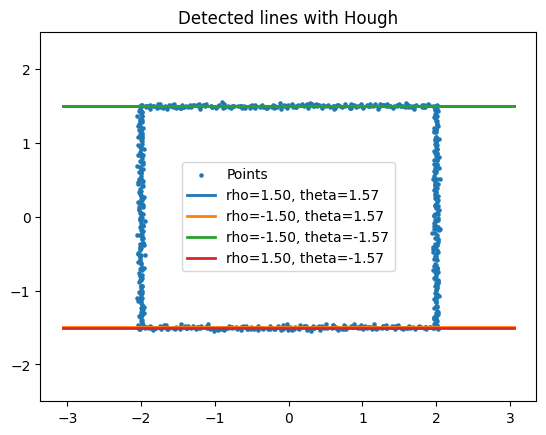

In [5]:
def plot_hough_lines(x, y, peaks, rhos, thetas):
    plt.figure()
    plt.scatter(x, y, s=5, label='Points')

    xs = np.linspace(x.min()-1, x.max()+1, 1000)
    for r_idx, t_idx in peaks:
        rho = rhos[r_idx]
        theta = thetas[t_idx]

        # Line: x*cos(theta) + y*sin(theta) = rho
        if np.abs(np.sin(theta)) > 1e-6:
            ys = (rho - xs * np.cos(theta)) / np.sin(theta)
        else:
            xs_line = np.full_like(xs, rho / np.cos(theta))
            ys = np.linspace(y.min()-1, y.max()+1, len(xs))
            xs = xs_line

        plt.plot(xs, ys, linewidth=2, label=f"rho={rho:.2f}, theta={theta:.2f}")

    plt.axis('equal')
    plt.legend()
    plt.title("Detected lines with Hough")
    plt.show()

plot_hough_lines(x, y, peaks, rhos, thetas)


#Task 1.2

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required in some Matplotlib setups

np.random.seed(0)


In [12]:
def generate_ground_with_obstacles(
    n_ground=2000, n_obstacles=500,
    ground_z=0.0, ground_noise=0.01
):
    # Ground: plane z = ground_z + noise over a rectangle
    xg = np.random.uniform(-5, 5, n_ground)
    yg = np.random.uniform(-5, 5, n_ground)
    zg = ground_z + np.random.normal(scale=ground_noise, size=n_ground)
    ground = np.vstack([xg, yg, zg]).T

    # Obstacles: random points above ground
    xo = np.random.uniform(-3, 3, n_obstacles)
    yo = np.random.uniform(-3, 3, n_obstacles)
    zo = np.random.uniform(0.3, 2.0, n_obstacles)
    obstacles = np.vstack([xo, yo, zo]).T

    points = np.vstack([ground, obstacles])
    return points

points = generate_ground_with_obstacles()
points.shape


(2500, 3)

In [13]:
def plane_from_points(p1, p2, p3, eps=1e-6):
    """
    Given 3 points p1, p2, p3 (3D), return plane parameters (a, b, c, d)
    for ax + by + cz + d = 0, with normalized (a, b, c).
    """
    v1 = p2 - p1
    v2 = p3 - p1
    n = np.cross(v1, v2)  # normal vector

    if np.linalg.norm(n) < eps:
        return None  # nearly collinear

    a, b, c = n
    d = -np.dot(n, p1)

    norm = np.linalg.norm([a, b, c])
    a, b, c, d = a / norm, b / norm, c / norm, d / norm
    return a, b, c, d


In [14]:
def distances_to_plane(points, plane):
    """
    points: (N, 3)
    plane: (a, b, c, d)
    returns |ax + by + cz + d| for each point, since (a, b, c) is normalized.
    """
    a, b, c, d = plane
    normal = np.array([a, b, c])
    return np.abs(points @ normal + d)


In [15]:
def ransac_plane(points, distance_threshold=0.02, n_iterations=500):
    """
    Basic RANSAC to find dominant plane in 3D point cloud.
    """
    best_inliers = None
    best_plane = None
    n_points = points.shape[0]

    for _ in range(n_iterations):
        # 1) Sample 3 random points
        idx = np.random.choice(n_points, 3, replace=False)
        p1, p2, p3 = points[idx]

        # 2) Fit plane
        plane = plane_from_points(p1, p2, p3)
        if plane is None:
            continue

        # 3) Distances and inliers
        dists = distances_to_plane(points, plane)
        inliers = dists < distance_threshold

        # 4) Keep best hypothesis
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers = inliers
            best_plane = plane

    return best_plane, best_inliers

plane, inliers = ransac_plane(points, distance_threshold=0.03, n_iterations=500)
print("Plane parameters (a, b, c, d):", plane)
print("Number of inliers:", inliers.sum(), "/", points.shape[0])


Plane parameters (a, b, c, d): (np.float64(-6.04321163785019e-05), np.float64(-0.00014489661599049526), np.float64(-0.9999999876764648), np.float64(0.0004925033418484221))
Number of inliers: 1995 / 2500


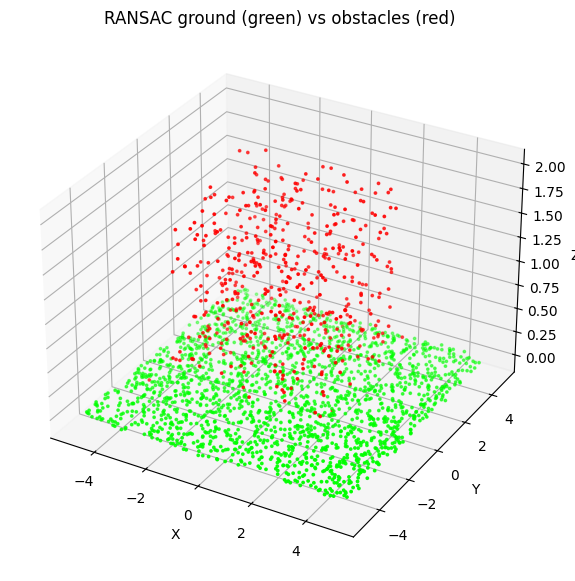

In [16]:
colors = np.zeros_like(points)
colors[inliers] = [0.0, 1.0, 0.0]   # ground = green
colors[~inliers] = [1.0, 0.0, 0.0]  # obstacles = red

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=colors, s=3)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('RANSAC ground (green) vs obstacles (red)')
plt.show()
